# Nasdaq 100 index

### Testing with ADF, SADF, GSADF and BSADF

In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
from matplotlib.ticker import FuncFormatter # for eg. 15.000 instead of 15000 on y-axis

# custom imports
%load_ext rpy2.ipython

##### 1. Download Nasdaq 100 index from 1. jan. 1990 to 31. dec. 2025

In [2]:
# Download Nasdaq 100, ticker = "^NDX" from yahoo finance
nasdaq = yf.Ticker("^NDX")
nasdaq_data = nasdaq.history(start="1990-01-01", end="2025-12-31", interval="1mo")
nasdaq_close = nasdaq_data["Close"]
log_nasdaq_close = np.log(nasdaq_close)

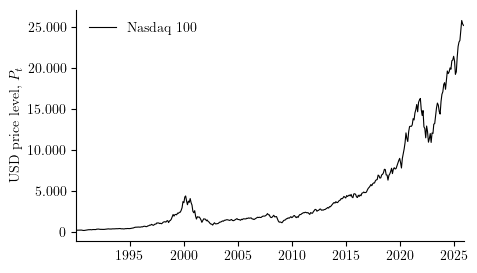

In [3]:
# LaTeX font settings
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# Plot
plt.figure(figsize=(5, 3)) # size to match latex document
plt.plot(nasdaq_close.index, nasdaq_close, color="black", ls="-", label=r"Nasdaq 100", linewidth=0.8)

#plt.xlabel(r"Time")
plt.ylabel(r"USD price level, $P_t$")
#plt.title(r"\textbf{Nasdaq 100 Index}")

# Fix x-axis
ax = plt.gca()
ax.set_xlim(nasdaq_close.index.min(), nasdaq_close.index.max())
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# fix y-axis to thousands seperators
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", ".")))

# plt.grid(True, alpha=0.7, ls="--")
plt.legend(frameon=False, loc='upper left')

# cleaner axes
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig("plots/nasdaq100.pdf", bbox_inches="tight")
plt.show()

We could also consider marking periods with explosiveness. Rough draft is made below. 

/opt/anaconda3/lib/python3.13/site-packages/matplotlib/dates.py:449: UserWarning: no explicit representation of timezones available for np.datetime64
  d = d.astype('datetime64[us]')


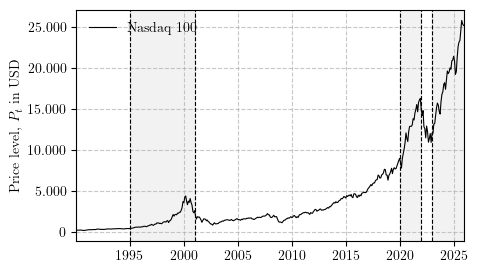

In [14]:
# LaTeX font settings
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# Plot
plt.figure(figsize=(5, 3))
plt.plot(nasdaq_close.index, nasdaq_close, color="black", ls="-",
         label=r"Nasdaq 100", linewidth=0.8)

plt.ylabel(r"Price level, $P_t$ in USD")

ax = plt.gca()

# --------- PERIODER ---------
# Dot-com bubble
start1 = pd.Timestamp("1995-01-01")
end1   = pd.Timestamp("2001-01-01")

# Post-COVID surge
start2 = pd.Timestamp("2020-01-01")
end2   = pd.Timestamp("2022-01-01")

# AI bubble
start3 = pd.Timestamp("2023-01-01")
end3   = nasdaq_close.index.max()

# --------- LODRETTE LINJER ---------
for date in [start1, end1, start2, end2, start3]:
    plt.axvline(date, color="black", linestyle="--", linewidth=0.8)

# --------- SHADING (anbefalet) ---------
ax.axvspan(start1, end1, alpha=0.1, color="grey")
ax.axvspan(start2, end2, alpha=0.1, color="grey")
ax.axvspan(start3, end3, alpha=0.1, color="grey")

# --------- AKSE FORMATERING ---------
ax.set_xlim(nasdaq_close.index.min(), nasdaq_close.index.max())
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", ".")))

plt.grid(True, alpha=0.7, ls="--")
plt.legend(frameon=False, loc='upper left')

plt.savefig("plots/nasdaq100.pdf", bbox_inches="tight")
plt.show()

In [15]:
# download log and close as .csv
nasdaq_close.to_csv("data/nasdaq100.csv")
log_nasdaq_close.to_csv("data/log_nasdaq100.csv")

##### 2. We now display results of testing Nasdaq 100 index from 1. jan. 1990 to 31. dec. 2025
Results on untransformed prices, $P_t$:

In [16]:
%%R
library(exuber)

# 1. Load series
dat <- read.csv('data/nasdaq100.csv') #../../data/simulated/timeseries/P_late_bubble.csv
y   <- ts(dat$Close)     # change after $ to the column name
T   <- length(y)

# 2. Test statistics (ADF, SADF, GSADF)
res  <- radf(y, lag = 0)

# 3. Critical values (Monte Carlo)
cv   <- radf_mc_cv(n = T, nrep = 2000, seed = 123)

options(digits = 10)
print(res)
print(cv)

# BSADF critical values (90%, 95%, 99%) and test statistic
cv$bsadf_cv # cv
res$bsadf   # test statistic

# download BSADF data

# BSADF test statistic over time
bsadf_stat <- data.frame(bsadf = as.numeric(res$bsadf))
write.csv(bsadf_stat, "results/nasdaq100_bsadf_stat.csv", row.names = FALSE)

# BSADF critical values (90, 95, 99)
bsadf_cv <- as.data.frame(cv$bsadf_cv)        # keep all significance-level columns
write.csv(bsadf_cv, "results/nasdaq100_bsadf_cv.csv", row.names = FALSE)




── radf (minw = 41, lag = 0) ───────────────────────────────────────────────────

       id      adf      sadf     gsadf
  series1  4.15407  6.256398  6.256398

  gsadf_panel
     6.256398


── Monte Carlo (minw = 41, nrep = 2000) ────────────────────────────────────────

  sig          adf      sadf     gsadf
   90  -0.39620743  1.151958  1.940131
   95  -0.03740744  1.450801  2.165954
   99   0.63280779  2.039598  2.622547



BSADF with untransformed prices, $P_t$:

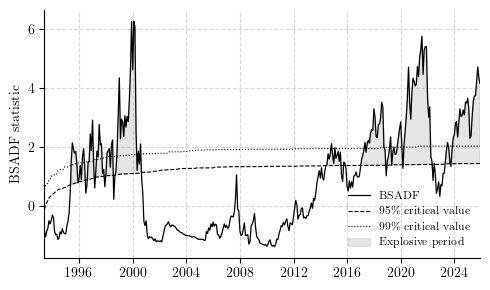

In [17]:
# font / latex style
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# load data
bsadf_stat = pd.read_csv("results/nasdaq100_bsadf_stat.csv")
bsadf_cv   = pd.read_csv("results/nasdaq100_bsadf_cv.csv")

t = nasdaq_close.index[-len(bsadf_stat):]

# plot
plt.figure(figsize=(5, 3))

plt.plot(t, bsadf_stat["bsadf"],
         color='black', linewidth=0.9, ls='-',
         label='BSADF')

plt.plot(t, bsadf_cv["95%"],
         color='black', linewidth=0.8, ls='--',
         label='95\\% critical value')

plt.plot(t, bsadf_cv["99%"],
         color='black', linewidth=0.8, ls=':',
         label='99\\% critical value')

plt.fill_between(t, # optional shading of explosive periods for 95% cv
                 bsadf_stat["bsadf"],
                 bsadf_cv["95%"],
                 where=(bsadf_stat["bsadf"] > bsadf_cv["95%"]),
                 color='grey',
                 alpha=0.2,
                 label='Explosive period')

# labels
plt.ylabel('BSADF statistic')

# formatting
plt.tight_layout()
plt.grid(True, alpha=0.5, linestyle='--')
plt.legend(frameon=False, loc='lower right', fontsize=8)

plt.xlim(t.min(), t.max())

# cleaner axes
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# save
plt.savefig("plots/nasdaq100_bsadf.pdf", bbox_inches="tight")
plt.show()

We now examine for which periods the test statistic exceeds the critical value on the 95% confidence interval in the format of year-month-date.

In [18]:
# boolean serie: hvor BSADF > 95% kritisk værdi
is_explosive = bsadf_stat["bsadf"] > bsadf_cv["95%"]

# konverter til DataFrame med tidsindeks
df = pd.DataFrame({
    "date": t,
    "explosive": is_explosive
}).set_index("date")

# identificer start/slut på perioder
df["group"] = (df["explosive"] != df["explosive"].shift()).cumsum()

# behold kun perioder hvor explosive = True
periods = (
    df[df["explosive"]]
    .groupby("group")
    .apply(lambda x: pd.Series({
        "start": x.index.min(),
        "end": x.index.max(),
        "length": len(x)
    }))
    .reset_index(drop=True)
)

print(periods)

                       start                       end  length
0  1995-06-01 00:00:00-04:00 1995-11-01 00:00:00-05:00       6
1  1996-01-01 00:00:00-05:00 1996-06-01 00:00:00-04:00       6
2  1996-09-01 00:00:00-04:00 1997-02-01 00:00:00-05:00       6
3  1997-04-01 00:00:00-05:00 1997-11-01 00:00:00-05:00       8
4  1998-01-01 00:00:00-05:00 1998-07-01 00:00:00-04:00       7
5  1998-10-01 00:00:00-04:00 2000-08-01 00:00:00-04:00      23
6  2014-07-01 00:00:00-04:00 2015-07-01 00:00:00-04:00      13
7  2015-10-01 00:00:00-04:00 2015-11-01 00:00:00-04:00       2
8  2017-02-01 00:00:00-05:00 2018-11-01 00:00:00-04:00      22
9  2019-01-01 00:00:00-05:00 2019-04-01 00:00:00-04:00       4
10 2019-06-01 00:00:00-04:00 2020-02-01 00:00:00-05:00       9
11 2020-04-01 00:00:00-04:00 2022-05-01 00:00:00-04:00      26
12 2022-07-01 00:00:00-04:00 2022-07-01 00:00:00-04:00       1
13 2023-05-01 00:00:00-04:00 2023-09-01 00:00:00-04:00       5
14 2023-11-01 00:00:00-04:00 2025-12-01 00:00:00-05:00 

/var/folders/q8/8mwdlsqx1fl6m13c32p9l0hw0000gn/T/ipykernel_64767/931205393.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


Results on transformed prices, $\ln(P_t)$:

In [19]:
%%R
library(exuber)

# 1. Load series
dat <- read.csv('data/log_nasdaq100.csv') #../../data/simulated/timeseries/P_late_bubble.csv
y   <- ts(dat$Close)     # change after $ to the column name
T   <- length(y)

# 2. Test statistics (ADF, SADF, GSADF)
res  <- radf(y, lag = 0)

# 3. Critical values (Monte Carlo)
cv   <- radf_mc_cv(n = T, nrep = 2000, seed = 123)

options(digits = 10)
print(res)
print(cv)

# BSADF critical values (90%, 95%, 99%) and test statistic
cv$bsadf_cv # cv
res$bsadf   # test statistic

# download BSADF data

# BSADF test statistic over time
bsadf_stat <- data.frame(bsadf = as.numeric(res$bsadf))
write.csv(bsadf_stat, "results/log_nasdaq100_bsadf_stat.csv", row.names = FALSE)

# BSADF critical values (90, 95, 99)
bsadf_cv <- as.data.frame(cv$bsadf_cv)        # keep all significance-level columns
write.csv(bsadf_cv, "results/log_nasdaq100_bsadf_cv.csv", row.names = FALSE)


── radf (minw = 41, lag = 0) ───────────────────────────────────────────────────

       id        adf      sadf     gsadf
  series1  -0.553682  2.144492  2.568401

  gsadf_panel
     2.568401


── Monte Carlo (minw = 41, nrep = 2000) ────────────────────────────────────────

  sig          adf      sadf     gsadf
   90  -0.39620743  1.151958  1.940131
   95  -0.03740744  1.450801  2.165954
   99   0.63280779  2.039598  2.622547



BSADF with transformed prices, $\ln(P_t)$:

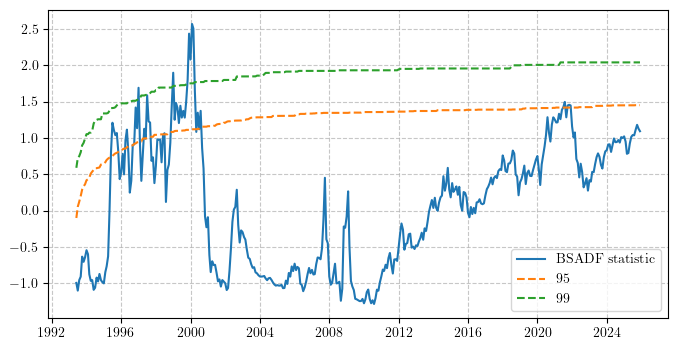

In [20]:
bsadf_stat = pd.read_csv("results/log_nasdaq100_bsadf_stat.csv")
bsadf_cv   = pd.read_csv("results/log_nasdaq100_bsadf_cv.csv")

t = log_nasdaq_close.index[-len(bsadf_stat):]

plt.figure(figsize=(8, 4))
plt.plot(t, bsadf_stat["bsadf"], label="BSADF statistic")
plt.plot(t, bsadf_cv["95%"], "--", label="95% critical value")
plt.plot(t, bsadf_cv["99%"], "--", label="99% critical value")
plt.legend()
plt.grid(True, alpha=0.7, ls="--")
plt.savefig("plots/log_nasdaq100_bsadf.pdf", bbox_inches="tight")
plt.show()

## From 2015

##### 1. Download Nasdaq 100 index from 1. jan. 2015 to 31. dec. 2025

In [21]:
# Download Nasdaq 100, ticker = "^NDX" from yahoo finance
nasdaq = yf.Ticker("^NDX")
nasdaq_data = nasdaq.history(start="2015-01-01", end="2025-12-31", interval="1mo")
nasdaq_close = nasdaq_data["Close"]
log_nasdaq_close = np.log(nasdaq_close)

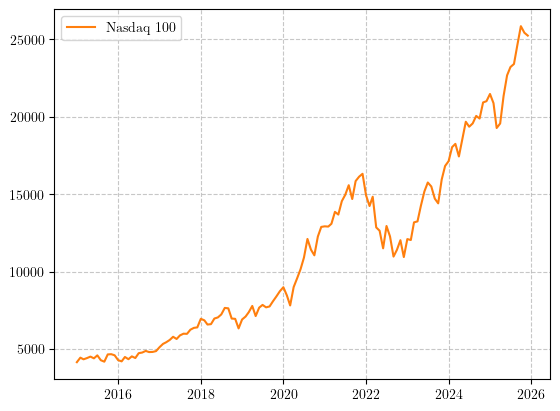

In [22]:
# Plot the Nasdaq 100 index
plt.plot(nasdaq_close.index, nasdaq_close, color="C1", ls="-", label="Nasdaq 100")
plt.grid(True, alpha=0.7, ls="--")
plt.legend()
plt.savefig("plots/2015_nasdaq100.pdf", bbox_inches="tight")
plt.show()

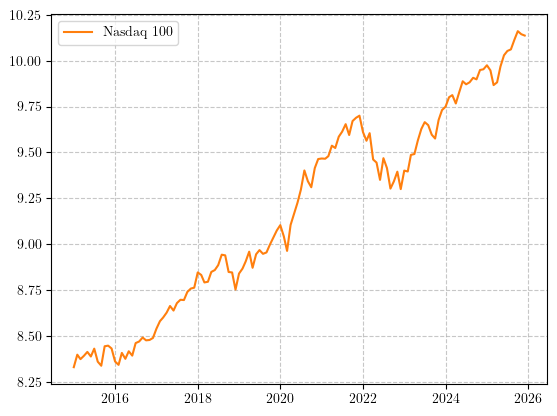

In [23]:
# Plot the Nasdaq 100 index with log scale
plt.plot(log_nasdaq_close.index, log_nasdaq_close, color="C1", ls="-", label="Nasdaq 100")
plt.grid(True, alpha=0.7, ls="--")
plt.legend()
plt.savefig("plots/2015_nasdaq100_log.pdf", bbox_inches="tight")
plt.show()

In [24]:
# download log and close as .csv
nasdaq_close.to_csv("data/2015_nasdaq100.csv")
log_nasdaq_close.to_csv("data/2015_log_nasdaq100.csv")

##### 2. We now display results of testing Nasdaq 100 index from 1. jan. 2015 to 31. dec. 2025
Results on untransformed prices, $P_t$:

In [25]:
%%R
library(exuber)

# 1. Load series
dat <- read.csv('data/2015_nasdaq100.csv') #../../data/simulated/timeseries/P_late_bubble.csv
y   <- ts(dat$Close)     # change after $ to the column name
T   <- length(y)

# 2. Test statistics (ADF, SADF, GSADF)
res  <- radf(y, lag = 0)

# 3. Critical values (Monte Carlo)
cv   <- radf_mc_cv(n = T, nrep = 2000, seed = 123)

options(digits = 10)
print(res)
print(cv)

# BSADF critical values (90%, 95%, 99%) and test statistic
cv$bsadf_cv # cv
res$bsadf   # test statistic

# download BSADF data

# BSADF test statistic over time
bsadf_stat <- data.frame(bsadf = as.numeric(res$bsadf))
write.csv(bsadf_stat, "results/2015_nasdaq100_bsadf_stat.csv", row.names = FALSE)

# BSADF critical values (90, 95, 99)
bsadf_cv <- as.data.frame(cv$bsadf_cv)        # keep all significance-level columns
write.csv(bsadf_cv, "results/2015_nasdaq100_bsadf_cv.csv", row.names = FALSE)


── radf (minw = 22, lag = 0) ───────────────────────────────────────────────────

       id       adf      sadf     gsadf
  series1  1.123593  2.301198  2.357987

  gsadf_panel
     2.357987


── Monte Carlo (minw = 22, nrep = 2000) ────────────────────────────────────────

  sig         adf      sadf     gsadf
   90  -0.4496014  1.002152  1.771418
   95  -0.1377478  1.330626  2.052327
   99   0.6666404  1.930828  2.631734



BSADF with untransformed prices, $P_t$:

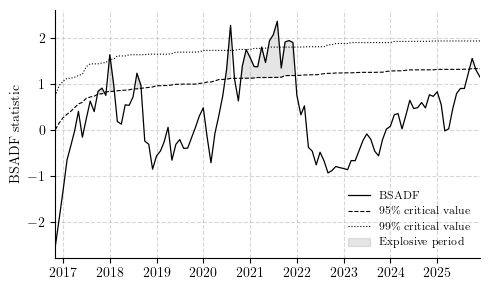

In [27]:
# font / latex style
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# load data
bsadf_stat = pd.read_csv("results/2015_nasdaq100_bsadf_stat.csv")
bsadf_cv   = pd.read_csv("results/2015_nasdaq100_bsadf_cv.csv")

t = nasdaq_close.index[-len(bsadf_stat):]

# plot
plt.figure(figsize=(5, 3))

plt.plot(t, bsadf_stat["bsadf"],
         color='black', linewidth=0.9, ls='-',
         label='BSADF')

plt.plot(t, bsadf_cv["95%"],
         color='black', linewidth=0.8, ls='--',
         label='95\\% critical value')

plt.plot(t, bsadf_cv["99%"],
         color='black', linewidth=0.8, ls=':',
         label='99\\% critical value')

# shading (eksplosive perioder)
plt.fill_between(t,
                 bsadf_stat["bsadf"],
                 bsadf_cv["95%"],
                 where=(bsadf_stat["bsadf"] > bsadf_cv["95%"]),
                 color='grey',
                 alpha=0.2,
                 label='Explosive period')

# labels
plt.ylabel('BSADF statistic')

# formatting
plt.tight_layout()
plt.grid(True, alpha=0.5, linestyle='--')
plt.legend(frameon=False, loc='lower right', fontsize=8)

plt.xlim(t.min(), t.max())

# cleaner axes
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# save
plt.savefig("plots/2015_nasdaq100_bsadf.pdf", bbox_inches="tight")
plt.show()

Results on transformed prices, $\ln(P_t)$:

In [20]:
%%R
library(exuber)

# 1. Load series
dat <- read.csv('data/2015_log_nasdaq100.csv') #../../data/simulated/timeseries/P_late_bubble.csv
y   <- ts(dat$Close)     # change after $ to the column name
T   <- length(y)

# 2. Test statistics (ADF, SADF, GSADF)
res  <- radf(y, lag = 0)

# 3. Critical values (Monte Carlo)
cv   <- radf_mc_cv(n = T, nrep = 2000, seed = 123)

options(digits = 10)
print(res)
print(cv)

# BSADF critical values (90%, 95%, 99%) and test statistic
cv$bsadf_cv # cv
res$bsadf   # test statistic

# download BSADF data

# BSADF test statistic over time
bsadf_stat <- data.frame(bsadf = as.numeric(res$bsadf))
write.csv(bsadf_stat, "results/2015_log_nasdaq100_bsadf_stat.csv", row.names = FALSE)

# BSADF critical values (90, 95, 99)
bsadf_cv <- as.data.frame(cv$bsadf_cv)        # keep all significance-level columns
write.csv(bsadf_cv, "results/2015_log_nasdaq100_bsadf_cv.csv", row.names = FALSE)


── radf (minw = 22, lag = 0) ───────────────────────────────────────────────────

       id         adf       sadf     gsadf
  series1  -0.2630258  0.8011474  1.095263

  gsadf_panel
     1.095263


── Monte Carlo (minw = 22, nrep = 2000) ────────────────────────────────────────

  sig         adf      sadf     gsadf
   90  -0.4496014  1.002152  1.771418
   95  -0.1377478  1.330626  2.052327
   99   0.6666404  1.930828  2.631734



BSADF with transformed prices, $\ln(P_t)$:

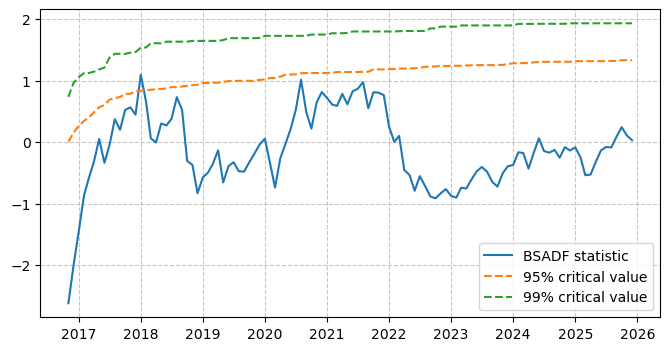

In [30]:
bsadf_stat = pd.read_csv("results/2015_log_nasdaq100_bsadf_stat.csv")
bsadf_cv   = pd.read_csv("results/2015_log_nasdaq100_bsadf_cv.csv")

t = log_nasdaq_close.index[-len(bsadf_stat):]

plt.figure(figsize=(8, 4))
plt.plot(t, bsadf_stat["bsadf"], label="BSADF statistic")
plt.plot(t, bsadf_cv["95%"], "--", label="95% critical value")
plt.plot(t, bsadf_cv["99%"], "--", label="99% critical value")
plt.legend()
plt.grid(True, alpha=0.7, ls="--")
plt.savefig("plots/2015_log_nasdaq100_bsadf.pdf", bbox_inches="tight")
plt.show()